# カメラ消費電流解析

nrf_camera_power_test.ino で取得した電流データを解析する。

**測定パターン**: 10秒録画 × 5回

**サイクル**: カメラESP32電源ON → 2秒ブート → 録画 → 停止 → 電源OFF → 5秒インターバル

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Meiryo'
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 設定
# ============================================================
CSV_FILE = 'dist/current_log.csv'

START_TIME = '2026-03-18 16:44:00'
END_TIME = '2026-03-18 16:50:30'

ON_THRESHOLD_MA = 30.0

REPS = 5
RECORD_SEC = 60

In [8]:
# ============================================================
# データ読み込み
# ============================================================
df = pd.read_csv(CSV_FILE)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

if START_TIME:
    df = df[df['Timestamp'] >= pd.to_datetime(START_TIME)]
if END_TIME:
    df = df[df['Timestamp'] <= pd.to_datetime(END_TIME)]

df = df.reset_index(drop=True)
df['elapsed_s'] = (df['Timestamp'] - df['Timestamp'].iloc[0]).dt.total_seconds()

print(f'データ件数: {len(df)}')
print(f'時間範囲: {df["Timestamp"].iloc[0]} ~ {df["Timestamp"].iloc[-1]}')
print(f'サンプリング間隔: {df["elapsed_s"].diff().median()*1000:.1f} ms')

データ件数: 7661
時間範囲: 2026-03-18 16:44:00.034760 ~ 2026-03-18 16:50:29.973864
サンプリング間隔: 50.8 ms


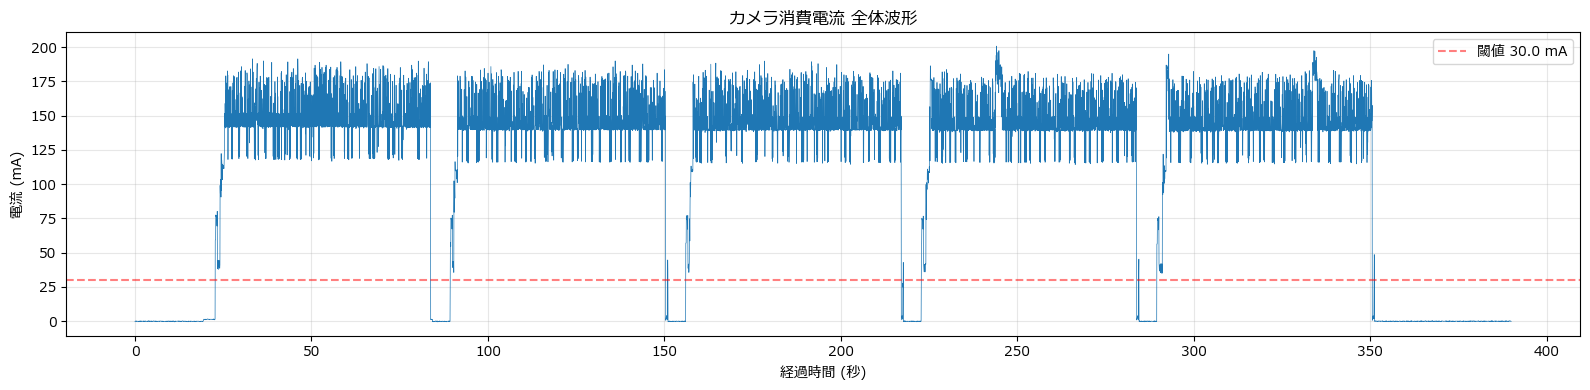

In [9]:
# ============================================================
# 全体の電流波形
# ============================================================
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df['elapsed_s'], df['Current (mA)'], linewidth=0.5)
ax.set_xlabel('経過時間 (秒)')
ax.set_ylabel('電流 (mA)')
ax.set_title('カメラ消費電流 全体波形')
ax.axhline(y=ON_THRESHOLD_MA, color='r', linestyle='--', alpha=0.5, label=f'閾値 {ON_THRESHOLD_MA} mA')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# カメラON区間の自動検出
# ============================================================
current = df['Current (mA)'].values
timestamps = df['elapsed_s'].values

is_on = current > ON_THRESHOLD_MA
transitions = np.diff(is_on.astype(int))
on_starts = np.where(transitions == 1)[0] + 1
on_ends = np.where(transitions == -1)[0] + 1

if is_on[0]:
    on_starts = np.insert(on_starts, 0, 0)
if is_on[-1]:
    on_ends = np.append(on_ends, len(is_on))

n_cycles = min(len(on_starts), len(on_ends))
on_starts = on_starts[:n_cycles]
on_ends = on_ends[:n_cycles]

# 1秒未満のスパイクを除外
valid = []
for s, e in zip(on_starts, on_ends):
    duration = timestamps[min(e, len(timestamps)-1)] - timestamps[s]
    if duration >= 1.0:
        valid.append((s, e))

print(f'検出されたON区間: {len(valid)} 回')
print(f'期待値: {REPS} 回')

検出されたON区間: 5 回
期待値: 5 回


In [11]:
# ============================================================
# 各ON区間の統計
# ============================================================
results = []

for i, (s, e) in enumerate(valid):
    segment = df.iloc[s:e]
    duration_s = segment['elapsed_s'].iloc[-1] - segment['elapsed_s'].iloc[0]
    mean_ma = segment['Current (mA)'].mean()
    peak_ma = segment['Current (mA)'].max()

    results.append({
        'cycle': i + 1,
        'duration_s': duration_s,
        'mean_mA': mean_ma,
        'peak_mA': peak_ma,
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

print(f'\n=== 集計 ===')
print(f'ON区間平均: {df_results["duration_s"].mean():.1f} 秒')
print(f'平均電流: {df_results["mean_mA"].mean():.1f} mA (標準偏差: {df_results["mean_mA"].std():.1f})')
print(f'ピーク電流: {df_results["peak_mA"].max():.1f} mA')

# ベースライン
all_on_indices = set()
for s, e in valid:
    all_on_indices.update(range(s, e))
off_mask = ~df.index.isin(all_on_indices)
baseline = df.loc[off_mask, 'Current (mA)'].mean()
print(f'ベースライン電流 (カメラ OFF): {baseline:.2f} mA')

 cycle  duration_s    mean_mA  peak_mA
     1   60.986276 147.739900    191.4
     2   60.961580 145.976936    189.9
     3   61.011458 146.005912    189.8
     4   60.936338 145.183639    200.7
     5   60.986655 144.877648    197.4

=== 集計 ===
ON区間平均: 61.0 秒
平均電流: 146.0 mA (標準偏差: 1.1)
ピーク電流: 200.7 mA
ベースライン電流 (カメラ OFF): 0.39 mA


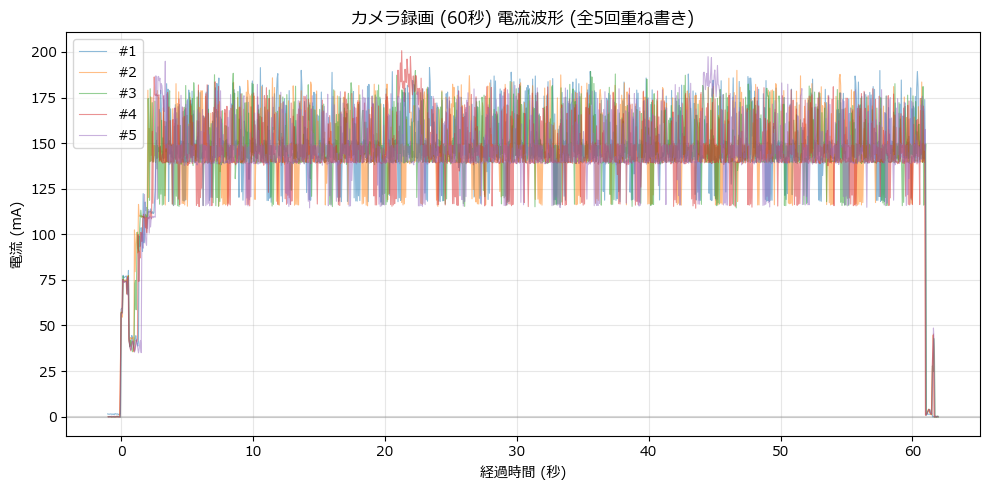

In [12]:
# ============================================================
# 全回の電流波形 (重ね書き)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

for i, (s, e) in enumerate(valid):
    margin = int(1.0 / (df['elapsed_s'].diff().median()))
    s_ext = max(0, s - margin)
    e_ext = min(len(df), e + margin)
    segment = df.iloc[s_ext:e_ext]
    t = segment['elapsed_s'].values - df.iloc[s]['elapsed_s']
    ax.plot(t, segment['Current (mA)'].values, alpha=0.5, linewidth=0.8, label=f'#{i+1}')

ax.set_xlabel('経過時間 (秒)')
ax.set_ylabel('電流 (mA)')
ax.set_title(f'カメラ録画 ({RECORD_SEC}秒) 電流波形 (全{len(valid)}回重ね書き)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()